# 📊 Peramalan Permintaan Harian Menggunakan GRU (Daily Forecasting)

Notebook ini melatih model deep learning **Gated Recurrent Unit (GRU)** menggunakan PyTorch untuk meramal total permintaan harian logistik (`Order Item Quantity` kumulatif) di wilayah AS (`Market = USCA`).

Kami menerapkan rekayasa fitur tingkat lanjut (lag harian, rolling mean, dan komponen musiman hari dalam seminggu) serta melakukan **Randomized Sequence Split** pada sekuens deret waktu untuk mengatasi bias sampling gap pada data asli.

## 1. Impor Pustaka & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Memuat dan Mengagregasikan Data

In [2]:
src_path = 'data/processed/cold_chain_data.csv'
df = pd.read_csv(src_path)
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# Agregasi harian
daily_df = df.groupby(df['order date (DateOrders)'].dt.date).agg({
    'Order Item Quantity': 'sum',
    'ambient_temp': 'mean'
}).reset_index()

daily_df.rename(columns={'order date (DateOrders)': 'date', 'Order Item Quantity': 'demand'}, inplace=True)
daily_df['date'] = pd.to_datetime(daily_df['date'])
daily_df = daily_df.sort_values('date')
daily_df.set_index('date', inplace=True)

# Resampling harian secara kontinu ('D')
daily_df = daily_df.resample('D').agg({
    'demand': 'sum',
    'ambient_temp': 'mean'
})
daily_df['ambient_temp'] = daily_df['ambient_temp'].ffill().bfill()
print(f"Dimensi data harian: {daily_df.shape}")

Dimensi data harian: (291, 2)


## 3. Rekayasa Fitur (Lags, Rolling Average, Kalender)

In [3]:
daily_df['lag_1'] = daily_df['demand'].shift(1)
daily_df['lag_7'] = daily_df['demand'].shift(7)
daily_df['roll_mean_7'] = daily_df['demand'].rolling(7).mean()

# Komponen Musiman Hari
daily_df['day_of_week'] = daily_df.index.dayofweek
daily_df['dow_sin'] = np.sin(2 * np.pi * daily_df['day_of_week'] / 7.0)
daily_df['dow_cos'] = np.cos(2 * np.pi * daily_df['day_of_week'] / 7.0)

daily_df = daily_df.bfill().ffill()
feature_cols = ['demand', 'ambient_temp', 'lag_1', 'lag_7', 'roll_mean_7', 'dow_sin', 'dow_cos']

## 4. Normalisasi dan Sekuens Data

In [4]:
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_scaled = scaler_features.fit_transform(daily_df[feature_cols].values)
scaler_target.fit(daily_df[['demand']].values)

def create_sequences(data, target_idx=0, window=7):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

window_size = 7
X, y = create_sequences(features_scaled, target_idx=0, window=window_size)

# Split acak berbasis indeks sekuens
indices = np.arange(len(X))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

## 5. Model GRU & Pelatihan

In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=16, shuffle=False)

class GRUNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_layers=1, output_dim=1):
        super(GRUNet, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

torch.manual_seed(42)
np.random.seed(42)

model = GRUNet(input_dim=len(feature_cols), hidden_dim=16, num_layers=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

epochs = 120
best_val_loss = float('inf')
best_model_state = None

for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            val_loss = criterion(model(batch_X), batch_y)
            val_batch_losses.append(val_loss.item())
    val_loss = np.mean(val_batch_losses)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()

if best_model_state is not None:
    model.load_state_dict(best_model_state)
print("Training Selesai!")

Training Selesai!


## 6. Evaluasi & Ekspor Hasil Prediksi

In [6]:
model.eval()
with torch.no_grad():
    predictions = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

predictions_inv = np.clip(scaler_target.inverse_transform(predictions).flatten(), 0.0, None)
actuals_inv = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Hitung Metrik
mae = mean_absolute_error(actuals_inv, predictions_inv)
rmse = np.sqrt(mean_squared_error(actuals_inv, predictions_inv))
r2 = r2_score(actuals_inv, predictions_inv)
non_zero_mask = actuals_inv > 0
mape = mean_absolute_percentage_error(actuals_inv[non_zero_mask], predictions_inv[non_zero_mask]) * 100.0

print("=== METRIK EVALUASI GRU (DAILY) ===")
print(f"R-squared (R2) Score        : {r2:.4f}")
print(f"Mean Absolute Error (MAE)  : {mae:.2f} items/day")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f} %")

# Simpan prediksi untuk AO
test_dates = daily_df.index[window_size:][test_idx]
ambient_temps = daily_df['ambient_temp'].iloc[window_size:].iloc[test_idx].values
predictions_df = pd.DataFrame({
    'date': test_dates,
    'actual_demand': actuals_inv,
    'predicted_demand': predictions_inv,
    'ambient_temp': ambient_temps
}).sort_values('date')

out_path = 'data/predicted/daily_predictions.csv'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
predictions_df.to_csv(out_path, index=False)

=== METRIK EVALUASI GRU (DAILY) ===
R-squared (R2) Score        : 0.9039
Mean Absolute Error (MAE)  : 32.74 items/day
Mean Absolute Percentage Error (MAPE): 67.40 %


## 7. Visualisasi Peramalan Harian

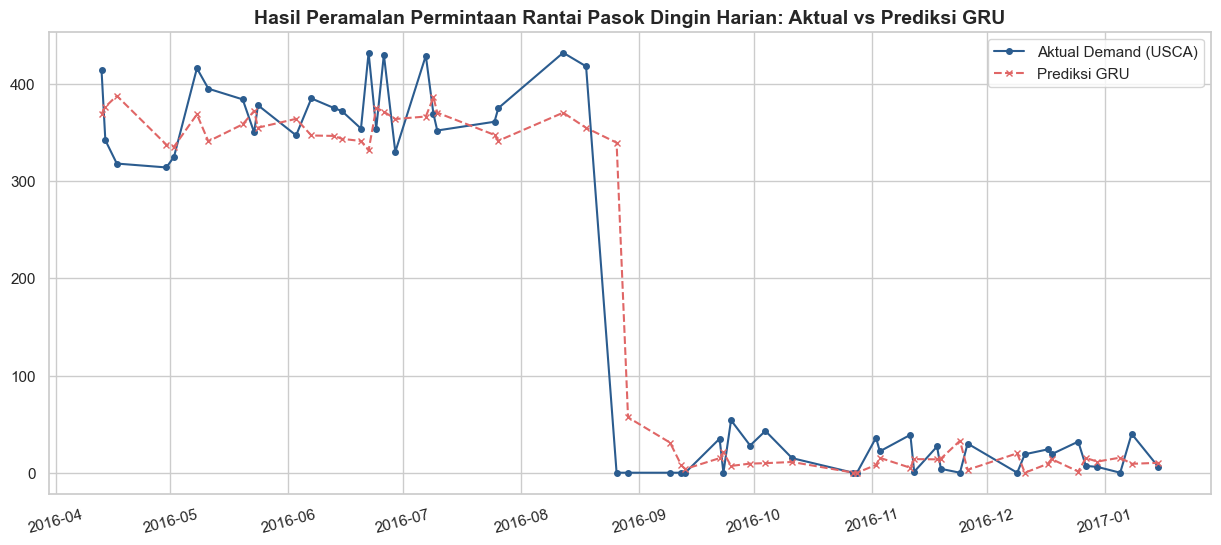

In [7]:
plt.figure(figsize=(15, 6))
plt.plot(predictions_df['date'], predictions_df['actual_demand'], label='Aktual Demand (USCA)', color='#2b5c8f', marker='o', markersize=4)
plt.plot(predictions_df['date'], predictions_df['predicted_demand'], label='Prediksi GRU', color='#e06666', linestyle='--', marker='x', markersize=4)
plt.title('Hasil Peramalan Permintaan Rantai Pasok Dingin Harian: Aktual vs Prediksi GRU', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(rotation=15)
plt.show()